# Assignment #4

## Problem 1: Predicting Useful Questions on Stack Exchange

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

# a)
Start by cleaning up the dataset to get it into a form where we can apply statistical learning methods to predict our dependent variable of interest.  

Please briefly describe each step that you took to clean and process the data.  Here are some suggestions:

In [2]:
stack_stats_train_og = pd.read_csv('stack_stats_2020_train.csv')
stack_stats_test_og = pd.read_csv('stack_stats_2020_test.csv')

In [3]:
# To be cleaned
stack_stats_train = pd.read_csv('stack_stats_2020_train.csv')
stack_stats_test = pd.read_csv('stack_stats_2020_test.csv')

## i) 
The Python library BeautifulSoup is useful for dealing with html text.  

In order to use this library, you will need to install it first by running the following command: conda install beautifulsoup4 in the terminal.  

In the code, you can import it by running the following line:from bs4 import BeautifulSoup

In [4]:
# %pip install beautifulsoup4

In [5]:
from bs4 import BeautifulSoup as bs

In [6]:
bs

bs4.BeautifulSoup

## ii)
 When  converting  html  texts  that  include  multiple  lines  of  texts  to  plain  texts  using get_text() from BeautifulSoup, the output texts still contain one type of html string,\n or the linebreak character.  
 
 In other words, get_text() does not remove the linebreak characters.  You will need to remove them using a proper method of your choice.

In [7]:
stack_stats_train.head()

,Id,Score,Body,Title,Tags
0,475417,5,<p>I often hear that in a longitudinal multi-l...,Are time points nested in students or crossed ...,<r><mixed-model><lme4-nlme><repeated-measures>...
1,454969,1,<p>I have a normally distributed dataset and a...,Find confidence level given a confidence interval,<r><probability><normal-distribution><confiden...
2,475651,0,<p>I have created a random forest to classify ...,Random Forest Classifier bound to a specific t...,<random-forest><feature-selection><error>
3,474736,0,<p>I have some issues with my linear differenc...,"How to back transform ln + 1 or log10 + 1, and...",<regression><logistic><multiple-regression><lo...
4,471570,1,<p>I have created a mixed model to model the n...,Interpret dotplot in mixed model,<r><regression><multilevel-analysis><model>


In [8]:
stack_stats_train['Body'][0]

'<p>I often hear that in a longitudinal multi-level analysis, time points (as a fixed factor) are <em>&quot;nested&quot;</em> within students (e.g., just search the word <span class="math-container">$nest$</span> in <a href="https://www.frontiersin.org/articles/10.3389/fpsyg.2018.00790/full" rel="nofollow noreferrer">this paper</a>).</p>\n<p>However, <a href="https://stats.stackexchange.com/a/228814/140365">this great answer</a> very clearly indicates that time points can\'t be <em>&quot;nested&quot;</em> within a cluster (e.g., a student). Because, every cluster is planned to taste every time point in theory. So time points and students are crossed.</p>\n<p><strong>Question:</strong> Is the use of the phrase <em>time points are <strong>&quot;nested&quot;</strong> within students</em> just sloppy language? If it is, how could we correctly describe the relation of the time points to students?</p>\n'

In [9]:
import re 
from string import punctuation

In [10]:
# Function to do all the cleaning. (12222) for reference
def clean(body):
    soup = bs(body, 'html.parser') # removing html tags
    soup = soup.get_text().lower() # turning all text into lowercase
    soup = ''.join([character for character in soup if not character.isdigit()]) # removing digits
    soup = ''.join([character for character in soup if character not in punctuation]) # removing punctuation
    pattern = r'\n' # removing all \n linebreak characters
    newstr = re.sub(pattern, '', soup)
    return newstr

#### Cleaning the 'Body' column

In [11]:
# Cleaning the 'Body' column in the stacks_stats training set
stack_stats_train['Body'] = stack_stats_train['Body'].apply(clean)

In [12]:
stack_stats_train['Body']

0        i often hear that in a longitudinal multilevel...
1        i have a normally distributed dataset and an a...
2        i have created a random forest to classify a d...
3        i have some issues with my linear differencein...
4        i have created a mixed model to model the numb...
                               ...                        
19242    ive read the post how deriving the formula for...
19243    i am doing a study on three groups of students...
19244    is there a neural network that can take data f...
19245    i am testing the following models volumes were...
19246    mahalanobis distance provides a value that mig...
Name: Body, Length: 19247, dtype: str

## iii) 
You should also inspect several texts from Body, Tags and Title to see if there is any other transformation needed.  

You may need to write a custom transformation function.

#### Cleaning the 'Title' column

In [13]:
# Cleaning the 'Title' column in the stacks_stats training set
stack_stats_train['Title'] = stack_stats_train['Title'].apply(clean)

#### Cleaning the 'Tags' column

In [14]:
# Cleaning the 'Tags' column in the stacks_stats training set
def clean_tags(tags_row):
    pattern = r'[^a-z]' # removing all non-alphabetical characters
    newstr = re.sub(pattern, ' ', tags_row)
    soup = bs(newstr, 'html.parser')
    return newstr

In [15]:
stack_stats_train['Tags'] = stack_stats_train['Tags'].apply(clean_tags)

In [16]:
stack_stats_train.head()

,Id,Score,Body,Title,Tags
0,475417,5,i often hear that in a longitudinal multilevel...,are time points nested in students or crossed ...,r mixed model lme nlme repeated measures ...
1,454969,1,i have a normally distributed dataset and an a...,find confidence level given a confidence interval,r probability normal distribution confiden...
2,475651,0,i have created a random forest to classify a d...,random forest classifier bound to a specific t...,random forest feature selection error
3,474736,0,i have some issues with my linear differencein...,how to back transform ln or log and interp...,regression logistic multiple regression lo...
4,471570,1,i have created a mixed model to model the numb...,interpret dotplot in mixed model,r regression multilevel analysis model


#### Cleaning the test data

In [17]:
stack_stats_test.head()

,Id,Score,Body,Title,Tags
0,501467,2,<p>So my problem is this:\nI have a toleranced...,Probability that two Parts selected from a Nor...,<probability><normal-distribution>
1,443609,1,<p>Let <strong>x</strong> and <strong>y</stron...,Expected value of product of 2 correlated rand...,<random-vector>
2,454571,1,<p>I want to compare the model fitting propert...,How to compare Random Forest and Gaussian Proc...,<random-forest><gaussian-process><fitting><mod...
3,463464,0,"<p>I do not understand the assumption 1,2,⋯ ar...",Why Asymptotic Equipartition Property theorem ...,<mathematical-statistics><markov-process><info...
4,493759,0,<p>Target encoding (aka mean or categorical en...,Target encoding categorical variables when pop...,<categorical-data><predictive-models><categori...


In [18]:
stack_stats_test['Body'] = stack_stats_test['Body'].apply(clean)
stack_stats_test['Title'] = stack_stats_test['Title'].apply(clean)
stack_stats_test['Tags'] = stack_stats_test['Tags'].apply(clean_tags)

In [19]:
stack_stats_test.head()

,Id,Score,Body,Title,Tags
0,501467,2,so my problem is thisi have a toleranced part ...,probability that two parts selected from a nor...,probability normal distribution
1,443609,1,let x and y be complex gaussian random vectors...,expected value of product of correlated rando...,random vector
2,454571,1,i want to compare the model fitting properties...,how to compare random forest and gaussian proc...,random forest gaussian process fitting mod...
3,463464,0,i do not understand the assumption ⋯ are iid p...,why asymptotic equipartition property theorem ...,mathematical statistics markov process info...
4,493759,0,target encoding aka mean or categorical encodi...,target encoding categorical variables when pop...,categorical data predictive models categori...


#### Combining both training and test

In [20]:
stack_stats_train['train'] = np.ones(len(stack_stats_train))

In [22]:
stack_stats_train.head()

,Id,Score,Body,Title,Tags,train
0,475417,5,i often hear that in a longitudinal multilevel...,are time points nested in students or crossed ...,r mixed model lme nlme repeated measures ...,1.0
1,454969,1,i have a normally distributed dataset and an a...,find confidence level given a confidence interval,r probability normal distribution confiden...,1.0
2,475651,0,i have created a random forest to classify a d...,random forest classifier bound to a specific t...,random forest feature selection error,1.0
3,474736,0,i have some issues with my linear differencein...,how to back transform ln or log and interp...,regression logistic multiple regression lo...,1.0
4,471570,1,i have created a mixed model to model the numb...,interpret dotplot in mixed model,r regression multilevel analysis model,1.0


In [24]:
stack_stats_test['train'] = np.zeros(len(stack_stats_test))

In [25]:
stack_stats_test.head()

,Id,Score,Body,Title,Tags,train
0,501467,2,so my problem is thisi have a toleranced part ...,probability that two parts selected from a nor...,probability normal distribution,0.0
1,443609,1,let x and y be complex gaussian random vectors...,expected value of product of correlated rando...,random vector,0.0
2,454571,1,i want to compare the model fitting properties...,how to compare random forest and gaussian proc...,random forest gaussian process fitting mod...,0.0
3,463464,0,i do not understand the assumption ⋯ are iid p...,why asymptotic equipartition property theorem ...,mathematical statistics markov process info...,0.0
4,493759,0,target encoding aka mean or categorical encodi...,target encoding categorical variables when pop...,categorical data predictive models categori...,0.0


In [27]:
# DataFrame.append() was removed in pandas 2.0 — it's no longer a method at all. 
# Use pd.concat() instead:
# stack_stats_df = stack_stats_train.append(stack_stats_test, ignore_index=True)
stack_stats_df = pd.concat([stack_stats_train, stack_stats_test], ignore_index=True)

stack_stats_df

,Id,Score,Body,Title,Tags,train
0,475417,5,i often hear that in a longitudinal multilevel...,are time points nested in students or crossed ...,r mixed model lme nlme repeated measures ...,1.0
1,454969,1,i have a normally distributed dataset and an a...,find confidence level given a confidence interval,r probability normal distribution confiden...,1.0
2,475651,0,i have created a random forest to classify a d...,random forest classifier bound to a specific t...,random forest feature selection error,1.0
3,474736,0,i have some issues with my linear differencein...,how to back transform ln or log and interp...,regression logistic multiple regression lo...,1.0
4,471570,1,i have created a mixed model to model the numb...,interpret dotplot in mixed model,r regression multilevel analysis model,1.0
...,...,...,...,...,...,...
27491,464503,1,i have collected bond yield data from for sev...,analyzing the impact on non standard monetary ...,least squares econometrics panel data,0.0
27492,495508,1,in a population of people there is a chance ...,accepting null hypothesis given specificity,bayesian p value,0.0
27493,455048,0,i ran a multiple logistic regression model sec...,multicolinearity in logistic regression using ...,regression logistic multicollinearity,0.0
27494,478353,2,i conduct a staggered differenceindifferences ...,differenceindifferences timevariant control va...,difference in difference,0.0


## iv) 
Once you have all texts in plain texts, you can use the Python library nltk to do text cleaning and generate document term matrices as we did in Lab.

In [29]:
import nltk 
from nltk.tokenize import word_tokenize 
from nltk.corpus import stopwords 
from nltk.stem import PorterStemmer 
from nltk.tokenize.treebank import TreebankWordDetokenizer
from sklearn.feature_extraction.text import CountVectorizer

### Tokenization, Stop Words, Stemming and DTM for "Body"

#### Tokenization

In [30]:
stack_stats_df['Body']

0        i often hear that in a longitudinal multilevel...
1        i have a normally distributed dataset and an a...
2        i have created a random forest to classify a d...
3        i have some issues with my linear differencein...
4        i have created a mixed model to model the numb...
                               ...                        
27491    i have collected bond yield data from  for sev...
27492    in a population of  people there is a  chance ...
27493    i ran a multiple logistic regression model sec...
27494    i conduct a staggered differenceindifferences ...
27495    x has a discrete distribution with support x x...
Name: Body, Length: 27496, dtype: str

In [31]:
text_tokenized = stack_stats_df['Body'].apply(word_tokenize)
text_tokenized.head()

0    [i, often, hear, that, in, a, longitudinal, mu...
1    [i, have, a, normally, distributed, dataset, a...
2    [i, have, created, a, random, forest, to, clas...
3    [i, have, some, issues, with, my, linear, diff...
4    [i, have, created, a, mixed, model, to, model,...
Name: Body, dtype: object

#### Removing the stop words

In [33]:
stop_words = set(stopwords.words('english'))

In [34]:
def remove_stopwords(document):
  
  words = [word for word in document if not word in stop_words]
  
  return words

In [35]:
text_no_stop = text_tokenized.apply(remove_stopwords)
text_no_stop

0        [often, hear, longitudinal, multilevel, analys...
1        [normally, distributed, dataset, associated, s...
2        [created, random, forest, classify, dataset, v...
3        [issues, linear, differenceindifference, analy...
4        [created, mixed, model, model, number, jobs, d...
                               ...                        
27491    [collected, bond, yield, data, several, eurozo...
27492    [population, people, chance, someone, cancer, ...
27493    [ran, multiple, logistic, regression, model, s...
27494    [conduct, staggered, differenceindifferences, ...
27495    [x, discrete, distribution, support, x, x, rig...
Name: Body, Length: 27496, dtype: object

#### Stemming

In [36]:
porter = PorterStemmer()

def stemmer(document):
  
  stemmed_document = [porter.stem(word) for word in document]
  
  return stemmed_document

In [37]:
text_stemmed = text_no_stop.apply(stemmer)
text_stemmed

0        [often, hear, longitudin, multilevel, analysi,...
1        [normal, distribut, dataset, associ, systemat,...
2        [creat, random, forest, classifi, dataset, var...
3        [issu, linear, differenceindiffer, analys, out...
4        [creat, mix, model, model, number, job, differ...
                               ...                        
27491    [collect, bond, yield, data, sever, eurozon, c...
27492    [popul, peopl, chanc, someon, cancer, fals, po...
27493    [ran, multipl, logist, regress, model, second,...
27494    [conduct, stagger, differenceindiffer, analysi...
27495    [x, discret, distribut, support, x, x, right, ...
Name: Body, Length: 27496, dtype: object

#### Document Term Matrix
To calculate frequencies of the words

In [38]:
# Detokenize the text first
text_detokenized = text_stemmed.apply(TreebankWordDetokenizer().detokenize)

In [39]:
countvec = CountVectorizer(min_df = 0.05) # Using words that appear in at least 5% of the texts

sparse_dtm = countvec.fit_transform(text_detokenized)
sparse_dtm

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 568010 stored elements and shape (27496, 191)>

CountVectorizer transforms our data into a 'Compressed Sparse Format' matrix. Storing the dtm in this format saves a lot of memory. We can then build a new pandas dataframe from this sparse dtm.

In [41]:
# get_feature_names() was removed in scikit-learn 1.0+ — replaced by get_feature_names_out():
# dtm = pd.DataFrame(sparse_dtm.toarray(), columns=countvec.get_feature_names(), index=stack_stats_df.index)

dtm = pd.DataFrame(sparse_dtm.toarray(), columns=countvec.get_feature_names_out(), index=stack_stats_df.index)
dtm

,abl,actual,algorithm,also,analysi,anoth,answer,anyon,appli,appreci,...,vector,want,way,weight,well,whether,without,wonder,work,would
0,0,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,1,...,0,2,0,0,0,0,0,0,1,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27491,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
27492,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
27493,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27494,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [42]:
frequencies = dtm.sum().sort_values(ascending=False)
frequencies

use        28838
model      28249
data       24667
variabl    18012
would      16171
           ...  
thought     1642
anyon       1598
pleas       1592
instead     1553
cant        1550
Length: 191, dtype: int64

### Tokenization, Stop Words, Stemming and DTM for "Title"

In [43]:
# Tokenization for "Title"
title_tokenized = stack_stats_df['Title'].apply(word_tokenize)
title_tokenized.head()

0    [are, time, points, nested, in, students, or, ...
1    [find, confidence, level, given, a, confidence...
2    [random, forest, classifier, bound, to, a, spe...
3    [how, to, back, transform, ln, or, log, and, i...
4               [interpret, dotplot, in, mixed, model]
Name: Title, dtype: object

In [44]:
# Removing stop words for "Title"
title_no_stop = title_tokenized.apply(remove_stopwords)
title_no_stop

0        [time, points, nested, students, crossed, long...
1        [find, confidence, level, given, confidence, i...
2        [random, forest, classifier, bound, specific, ...
3            [back, transform, ln, log, interpret, result]
4                       [interpret, dotplot, mixed, model]
                               ...                        
27491    [analyzing, impact, non, standard, monetary, p...
27492    [accepting, null, hypothesis, given, specificity]
27493    [multicolinearity, logistic, regression, using...
27494    [differenceindifferences, timevariant, control...
27495    [changing, one, point, discrete, distribution,...
Name: Title, Length: 27496, dtype: object

In [45]:
# Stemming for "Title"
title_stemmed = title_no_stop.apply(stemmer)
title_stemmed

0        [time, point, nest, student, cross, longitudin...
1             [find, confid, level, given, confid, interv]
2        [random, forest, classifi, bound, specif, type...
3            [back, transform, ln, log, interpret, result]
4                         [interpret, dotplot, mix, model]
                               ...                        
27491    [analyz, impact, non, standard, monetari, poli...
27492             [accept, null, hypothesi, given, specif]
27493    [multicolinear, logist, regress, use, final, f...
27494     [differenceindiffer, timevari, control, variabl]
27495    [chang, one, point, discret, distribut, maxim,...
Name: Title, Length: 27496, dtype: object

In [46]:
# Detokenize "Title"
title_detokenized = title_stemmed.apply(TreebankWordDetokenizer().detokenize)

In [47]:
# Count Vectorizer for "Title"
countvec = CountVectorizer(min_df = 0.05) # Using words that appear in at least 5% of the texts

title_sparse_dtm = countvec.fit_transform(title_detokenized)
title_sparse_dtm

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 21462 stored elements and shape (27496, 9)>

In [49]:
# DTM for "Title"
title_dtm = pd.DataFrame(title_sparse_dtm.toarray(), columns=countvec.get_feature_names_out(), index=stack_stats_df.index)
title_dtm

,data,differ,distribut,estim,model,regress,test,use,variabl
0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...
27491,0,0,0,0,0,0,0,0,0
27492,0,0,0,0,0,0,0,0,0
27493,0,0,0,0,0,1,0,1,0
27494,0,0,0,0,0,0,0,0,1


### Tokenization, Stop Words, Stemming and DTM for "Tags"

In [50]:
# Tokenization for "Tags"
tags_tokenized = stack_stats_df['Tags'].apply(word_tokenize)
tags_tokenized.head()

0    [r, mixed, model, lme, nlme, repeated, measure...
1    [r, probability, normal, distribution, confide...
2          [random, forest, feature, selection, error]
3    [regression, logistic, multiple, regression, l...
4         [r, regression, multilevel, analysis, model]
Name: Tags, dtype: object

In [51]:
# Removing stop words for "Tags"
tags_no_stop = tags_tokenized.apply(remove_stopwords)
tags_no_stop

0        [r, mixed, model, lme, nlme, repeated, measure...
1        [r, probability, normal, distribution, confide...
2              [random, forest, feature, selection, error]
3        [regression, logistic, multiple, regression, l...
4             [r, regression, multilevel, analysis, model]
                               ...                        
27491          [least, squares, econometrics, panel, data]
27492                                 [bayesian, p, value]
27493            [regression, logistic, multicollinearity]
27494                             [difference, difference]
27495      [probability, variance, discrete, data, bounds]
Name: Tags, Length: 27496, dtype: object

In [52]:
# Stemming for "Tags"
tags_stemmed = tags_no_stop.apply(stemmer)
tags_stemmed

0        [r, mix, model, lme, nlme, repeat, measur, mul...
1          [r, probabl, normal, distribut, confid, interv]
2                  [random, forest, featur, select, error]
3        [regress, logist, multipl, regress, logarithm,...
4                 [r, regress, multilevel, analysi, model]
                               ...                        
27491               [least, squar, econometr, panel, data]
27492                                  [bayesian, p, valu]
27493                    [regress, logist, multicollinear]
27494                                     [differ, differ]
27495             [probabl, varianc, discret, data, bound]
Name: Tags, Length: 27496, dtype: object

In [53]:
# Detokenize "Tags"
tags_detokenized = tags_stemmed.apply(TreebankWordDetokenizer().detokenize)

In [54]:
# Count Vectorizer for "Tags"
countvec = CountVectorizer(min_df = 0.05) # Using words that appear in at least 5% of the texts

tags_sparse_dtm = countvec.fit_transform(tags_detokenized)
tags_sparse_dtm

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 35252 stored elements and shape (27496, 13)>

In [56]:
# DTM for "Tags"
tags_dtm = pd.DataFrame(tags_sparse_dtm.toarray(), columns=countvec.get_feature_names_out(), index=stack_stats_df.index)
tags_dtm

,data,distribut,learn,machin,model,network,neural,probabl,regress,seri,statist,test,time
0,0,0,0,0,1,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,2,0,0,0,0
4,0,0,0,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27491,1,0,0,0,0,0,0,0,0,0,0,0,0
27492,0,0,0,0,0,0,0,0,0,0,0,0,0
27493,0,0,0,0,0,0,0,0,1,0,0,0,0
27494,0,0,0,0,0,0,0,0,0,0,0,0,0


## v) 
Notice  that  there  are  words  that  appear  in  more  than  one  column.   

For  instance, a question might have the term ‘regression’ in its title, body and tags.  
However, the terms ‘regression’ that appear at the three positions of this post may give different implications about  this  post.   

(For  example,  using  ‘regression’  in  the  title  may  signal  something different than ‘regression’ as a tag.) 

For this reason, the three types of text data that we are dealing with should be processed independently, and you should use different column names (e.g.,regression_title, regression_body, regression_tags

In [57]:
# Adding the suffix "body" to indicate different columns/features
dtm = dtm.add_suffix('_body')
dtm

,abl_body,actual_body,algorithm_body,also_body,analysi_body,anoth_body,answer_body,anyon_body,appli_body,appreci_body,...,vector_body,want_body,way_body,weight_body,well_body,whether_body,without_body,wonder_body,work_body,would_body
0,0,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,1,...,0,2,0,0,0,0,0,0,1,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27491,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
27492,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
27493,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27494,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [58]:
# Adding the suffix "title" to indicate different columns/features
title_dtm = title_dtm.add_suffix('_title')
title_dtm

,data_title,differ_title,distribut_title,estim_title,model_title,regress_title,test_title,use_title,variabl_title
0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...
27491,0,0,0,0,0,0,0,0,0
27492,0,0,0,0,0,0,0,0,0
27493,0,0,0,0,0,1,0,1,0
27494,0,0,0,0,0,0,0,0,1


In [60]:
# Adding the suffix "tags" to indicate different columns/features
tags_dtm = tags_dtm.add_suffix('_tags')
tags_dtm

,data_tags,distribut_tags,learn_tags,machin_tags,model_tags,network_tags,neural_tags,probabl_tags,regress_tags,seri_tags,statist_tags,test_tags,time_tags
0,0,0,0,0,1,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,2,0,0,0,0
4,0,0,0,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27491,1,0,0,0,0,0,0,0,0,0,0,0,0
27492,0,0,0,0,0,0,0,0,0,0,0,0,0
27493,0,0,0,0,0,0,0,0,1,0,0,0,0
27494,0,0,0,0,0,0,0,0,0,0,0,0,0


## b)
Use your analytics skills to build the best model that you can for predicting useful questions.  You are free to try whichever approaches you like, but you should try at least four distinct methods that have been discussed in class (e.g., Logistic Regression, LDA, CART, Random Forests, Boosting) and you should evaluate no more than a handful (i.e., 4-10) of candidate models on the test set.  

For Random Forests and Boosting, it is OK to not cross validate all of the parameters if it takes too much time on your computer – instead you may use some reasonable values of these parameters and/or only cross validate some of them. 

Report on the details of your training procedures and final comparisons on the test set.  Use your best judgment to choose a final model and explain your choice.  

Use the bootstrap to asses the performance of your single chosen final model in a way that properly reports on the variability of the relevant performance metrics (accuracy, TPR, and FPR).

In [61]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import time
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score 
from sklearn.metrics import mean_absolute_error

In [62]:
merged_dtms = pd.concat([dtm, title_dtm, tags_dtm], axis=1)

In [63]:
merged_dtms

,abl_body,actual_body,algorithm_body,also_body,analysi_body,anoth_body,answer_body,anyon_body,appli_body,appreci_body,...,machin_tags,model_tags,network_tags,neural_tags,probabl_tags,regress_tags,seri_tags,statist_tags,test_tags,time_tags
0,0,0,0,0,1,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27491,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27492,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27493,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
27494,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [64]:
# Retrieving the other columns such as the "Id", "score"(what we want to predict), and the "train" indicator
score_train = stack_stats_df[['Id', 'Score', 'train']]
score_train

,Id,Score,train
0,475417,5,1.0
1,454969,1,1.0
2,475651,0,1.0
3,474736,0,1.0
4,471570,1,1.0
...,...,...,...
27491,464503,1,0.0
27492,495508,1,0.0
27493,455048,0,0.0
27494,478353,2,0.0


In [65]:
# Merging those columns with the dtms we generated
merged_dtms_with_score = pd.concat([score_train, merged_dtms], axis=1)
merged_dtms_with_score

,Id,Score,train,abl_body,actual_body,algorithm_body,also_body,analysi_body,anoth_body,answer_body,...,machin_tags,model_tags,network_tags,neural_tags,probabl_tags,regress_tags,seri_tags,statist_tags,test_tags,time_tags
0,475417,5,1.0,0,0,0,0,1,0,1,...,0,1,0,0,0,0,0,0,0,0
1,454969,1,1.0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,475651,0,1.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,474736,0,1.0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
4,471570,1,1.0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27491,464503,1,0.0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
27492,495508,1,0.0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27493,455048,0,0.0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
27494,478353,2,0.0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [66]:
# Split BACK into the original training and test set
stack_stats_train = merged_dtms_with_score[merged_dtms_with_score['train'] == 1]
stack_stats_test = merged_dtms_with_score[merged_dtms_with_score['train'] == 0]

In [67]:
# Drop the "train" indicator column we made and the 'id' column(wont have any predictive power)
stack_stats_train = stack_stats_train.drop(['Id', 'train'], axis=1)
stack_stats_train

,Score,abl_body,actual_body,algorithm_body,also_body,analysi_body,anoth_body,answer_body,anyon_body,appli_body,...,machin_tags,model_tags,network_tags,neural_tags,probabl_tags,regress_tags,seri_tags,statist_tags,test_tags,time_tags
0,5,0,0,0,0,1,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19242,0,0,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,0
19243,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
19244,0,0,0,0,0,0,1,0,0,1,...,0,0,1,1,0,0,0,0,0,0
19245,2,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,1,0,0


In [68]:
stack_stats_test = stack_stats_test.drop(['Id', 'train'], axis=1)
stack_stats_test

,Score,abl_body,actual_body,algorithm_body,also_body,analysi_body,anoth_body,answer_body,anyon_body,appli_body,...,machin_tags,model_tags,network_tags,neural_tags,probabl_tags,regress_tags,seri_tags,statist_tags,test_tags,time_tags
19247,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
19248,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19249,1,0,0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
19250,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
19251,0,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27491,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27492,1,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27493,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
27494,2,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### X and y split for the training set

In [69]:
# y_training set
stack_stats_train_y = stack_stats_train['Score']
stack_stats_train_y

0        5
1        1
2        0
3        0
4        1
        ..
19242    0
19243    0
19244    0
19245    2
19246    1
Name: Score, Length: 19247, dtype: int64

In [70]:
# X training set
stack_stats_train_X = stack_stats_train.drop(['Score'], axis=1)
stack_stats_train_X

,abl_body,actual_body,algorithm_body,also_body,analysi_body,anoth_body,answer_body,anyon_body,appli_body,appreci_body,...,machin_tags,model_tags,network_tags,neural_tags,probabl_tags,regress_tags,seri_tags,statist_tags,test_tags,time_tags
0,0,0,0,0,1,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19242,0,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
19243,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
19244,0,0,0,0,0,1,0,0,1,0,...,0,0,1,1,0,0,0,0,0,0
19245,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0


### X and y split for the test set

In [71]:
stack_stats_test_X = stack_stats_test.drop(['Score'], axis=1)

In [72]:
stack_stats_test_y = stack_stats_test['Score']

In [74]:
stack_stats_test_y.nunique()

34

In [75]:
stack_stats_test_y.unique()

array([ 2,  1,  0,  3,  5,  4,  7, -1, 12, 16,  6, 10, -2,  8, 13,  9, 18,
       22, -3, 57, 14, 36, 24, 29, 30, 17, 37, 15, 11, 25, 27, 20, 51, 77])

### Baseline Model

In [76]:
#First determine what the majority class is (0 or 1)

# Original y_test converted to binary form
y_test_binary = (stack_stats_test_y >= 1).astype(int)

y_test_binary.value_counts()

Score
0    4173
1    4076
Name: count, dtype: int64

In [77]:
# Majority class is 0
baseline_acc = 4173/(4173+4076)
baseline_acc

0.5058795005455207

#### Metrics Functions

In [78]:
def custom_acc(predictions, y_test, y_train):
    return accuracy_score(y_test, predictions)

def tpr(predictions, y_test, y_train):
    cm = confusion_matrix(y_test, predictions)
    return cm.ravel()[3]/(cm.ravel()[3]+cm.ravel()[2])

def fpr(predictions, y_test, y_train):
    cm = confusion_matrix(y_test, predictions)
    return cm.ravel()[1]/(cm.ravel()[1]+cm.ravel()[0])

### Random Forests

* Checking the predictions. 

* Recall we are predicting whether or not a question is useful, based on its tags, title and body text data 

* Recall that a question is useful if its score is greater than or equal to one.

* Thus we will convert our predictions into binary form to check if the predicted score is greater than or equal to 1

In [80]:
stack_stats_train_y

0        5
1        1
2        0
3        0
4        1
        ..
19242    0
19243    0
19244    0
19245    2
19246    1
Name: Score, Length: 19247, dtype: int64

In [81]:
# Convert y_training to binary.
y_train_binary = (stack_stats_train_y >= 1).astype(int)
y_train_binary

0        1
1        1
2        0
3        0
4        1
        ..
19242    0
19243    0
19244    0
19245    1
19246    1
Name: Score, Length: 19247, dtype: int64

### Random Forests (Uses less of the features and R2 as the scoring metric)

* Shorter time to run since we know don't go past 50 features.

In [82]:
grid_values = {'max_features': np.linspace(1, 50, 5, dtype='int32'), 
               'min_samples_leaf': [5], 
               'n_estimators': [500], 
               'random_state': [88]}

tic = time.time()

rf = RandomForestRegressor()
# Note: here we set verbose=2 to keep track of the progress (the running time) of the cross validation. 
cv = KFold(n_splits=5, random_state=333, shuffle=True)
rf_cv = GridSearchCV(rf, param_grid=grid_values, scoring='r2', cv=cv, verbose=2)
rf_cv.fit(stack_stats_train_X, stack_stats_train_y)

toc = time.time()

print('time:', round(toc-tic, 2),'s')

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END max_features=1, min_samples_leaf=5, n_estimators=500, random_state=88; total time=   2.8s
[CV] END max_features=1, min_samples_leaf=5, n_estimators=500, random_state=88; total time=   2.8s
[CV] END max_features=1, min_samples_leaf=5, n_estimators=500, random_state=88; total time=   2.7s
[CV] END max_features=1, min_samples_leaf=5, n_estimators=500, random_state=88; total time=   2.6s
[CV] END max_features=1, min_samples_leaf=5, n_estimators=500, random_state=88; total time=   2.6s
[CV] END max_features=13, min_samples_leaf=5, n_estimators=500, random_state=88; total time=  11.9s
[CV] END max_features=13, min_samples_leaf=5, n_estimators=500, random_state=88; total time=  11.7s
[CV] END max_features=13, min_samples_leaf=5, n_estimators=500, random_state=88; total time=  11.8s
[CV] END max_features=13, min_samples_leaf=5, n_estimators=500, random_state=88; total time=  11.6s
[CV] END max_features=13, min_samples_leaf=5,

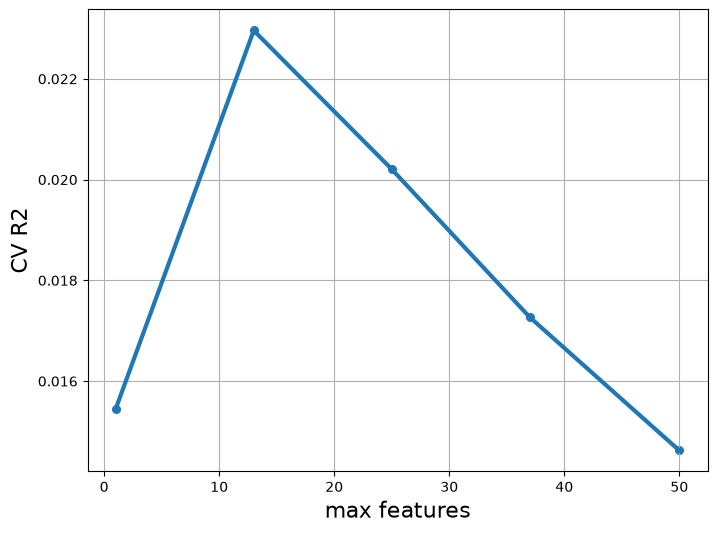

In [83]:
# Plotting the graph to determine the best hyperparameter 'm'
max_features = rf_cv.cv_results_['param_max_features'].data
R2_scores = rf_cv.cv_results_['mean_test_score']

plt.figure(figsize=(8, 6))
plt.xlabel('max features', fontsize=16)
plt.ylabel('CV R2', fontsize=16)
plt.scatter(max_features, R2_scores, s=30)
plt.plot(max_features, R2_scores, linewidth=3)
plt.grid(True, which='both')

In [84]:
print(rf_cv.best_params_)

{'max_features': np.int32(13), 'min_samples_leaf': 5, 'n_estimators': 500, 'random_state': 88}


In [85]:
### RF Mark 2 (Shorter time)
y_pred_binary = (rf_cv.predict(stack_stats_test_X) >= 1).astype(int)
y_pred_binary

array([1, 1, 0, ..., 0, 0, 1], shape=(8249,))

In [86]:
rf_acc = accuracy_score(y_test_binary, y_pred_binary)
rf_acc

0.5615226088010667

In [87]:
# Random Forests TPR
rf_tpr = tpr(y_pred_binary, y_test_binary, y_train_binary)
rf_tpr

np.float64(0.5328753680078508)

In [88]:
# Random Forests FPR
rf_fpr = fpr(y_pred_binary, y_test_binary, y_train_binary)
rf_fpr

np.float64(0.4104960460100647)

### Logistic Regression

In [89]:
# Convert y training to binary
y_train_binary = (stack_stats_train_y >= 1).astype(int)
y_train_binary

0        1
1        1
2        0
3        0
4        1
        ..
19242    0
19243    0
19244    0
19245    1
19246    1
Name: Score, Length: 19247, dtype: int64

In [90]:
logreg = LogisticRegression(random_state=88, max_iter=3000)
logreg.fit(stack_stats_train_X, y_train_binary)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",88
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",3000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [91]:
y_prob = logreg.predict_proba(stack_stats_test_X)
y_pred_log = pd.Series([1 if x > 0.5 else 0 for x in y_prob[:,1]])

In [92]:
cm = confusion_matrix(y_test_binary, y_pred_log)
print ("Confusion Matrix: \n", cm)
print ("\nAccuracy:", accuracy_score(y_test_binary, y_pred_log))
log_acc = accuracy_score(y_test_binary, y_pred_log)

Confusion Matrix: 
 [[2676 1497]
 [2108 1968]]

Accuracy: 0.5629773305855256


### Decision Tree Classifier

In [93]:
grid_values = {'ccp_alpha': np.linspace(0, 0.01, 30)}

dtc = DecisionTreeClassifier(random_state=88)
dtc_cv = GridSearchCV(dtc, param_grid=grid_values, cv=10).fit(stack_stats_train_X, y_train_binary)

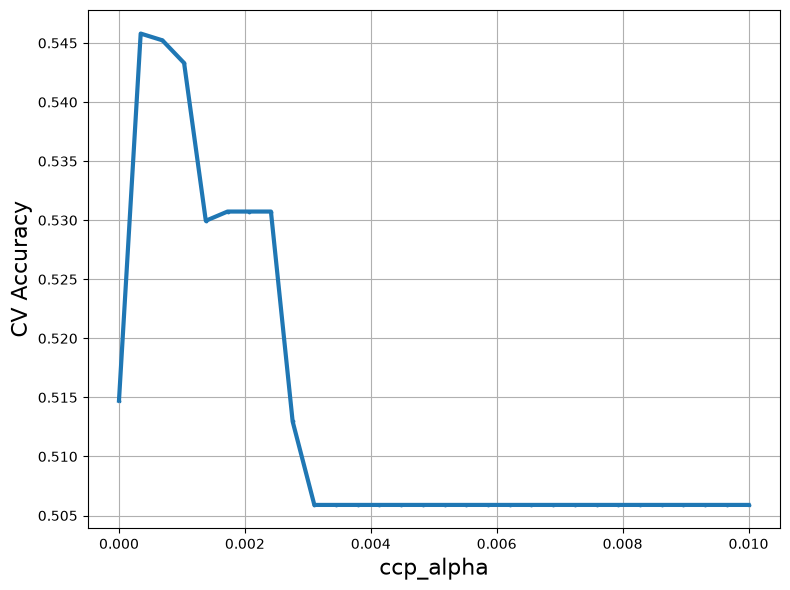

Best ccp_alpha {'ccp_alpha': np.float64(0.0003448275862068966)}


In [94]:
ccp_alpha = dtc_cv.cv_results_['param_ccp_alpha'].data
ACC_scores = dtc_cv.cv_results_['mean_test_score']

plt.figure(figsize=(8, 6))
plt.xlabel('ccp_alpha', fontsize=16)
plt.ylabel('CV Accuracy', fontsize=16)
plt.scatter(ccp_alpha, ACC_scores, s=3)
plt.plot(ccp_alpha, ACC_scores, linewidth=3)
plt.grid(True, which='both')

plt.tight_layout()
plt.show()

print('Best ccp_alpha', dtc_cv.best_params_)

In [95]:
y_pred_dtc = dtc_cv.predict(stack_stats_test_X)
cm2 = confusion_matrix(y_test_binary, y_pred_dtc)
print ("Confusion Matrix: \n", cm2)
print ("\nAccuracy:", accuracy_score(y_test_binary, y_pred_dtc))
dtc_acc = accuracy_score(y_test_binary, y_pred_dtc)

Confusion Matrix: 
 [[2500 1673]
 [2148 1928]]

Accuracy: 0.5367923384652685


In [96]:
# Decision Tree Classifier TPR
dtc_tpr = tpr(y_pred_dtc, y_test_binary, y_train_binary)
dtc_tpr

np.float64(0.4730127576054956)

In [97]:
# Decision Tree Classifier FPR
dtc_fpr = fpr(y_pred_dtc, y_test_binary, y_train_binary)
dtc_fpr

np.float64(0.4009106158638869)

### Gradient Boosting Classifier

In [98]:
from sklearn.ensemble import GradientBoostingClassifier

In [99]:
grid_values = {'n_estimators': np.linspace(1, 50, 5, dtype='int32'),  # np.logspace(6, 12, num=7, base=2, dtype='int32'),
               'learning_rate': [0.01],
               'max_leaf_nodes': np.linspace(2, 10, 8, dtype='int32'),
               'max_depth': [100],
               'min_samples_leaf': [10],
               'random_state': [88]} 

tic = time.time()

gbc = GradientBoostingClassifier()
gbc_cv = GridSearchCV(gbc, param_grid=grid_values, cv=5)
gbc_cv.fit(stack_stats_train_X, y_train_binary)

toc = time.time()

print('time:', round(toc-tic, 2),'s')

time: 361.91 s


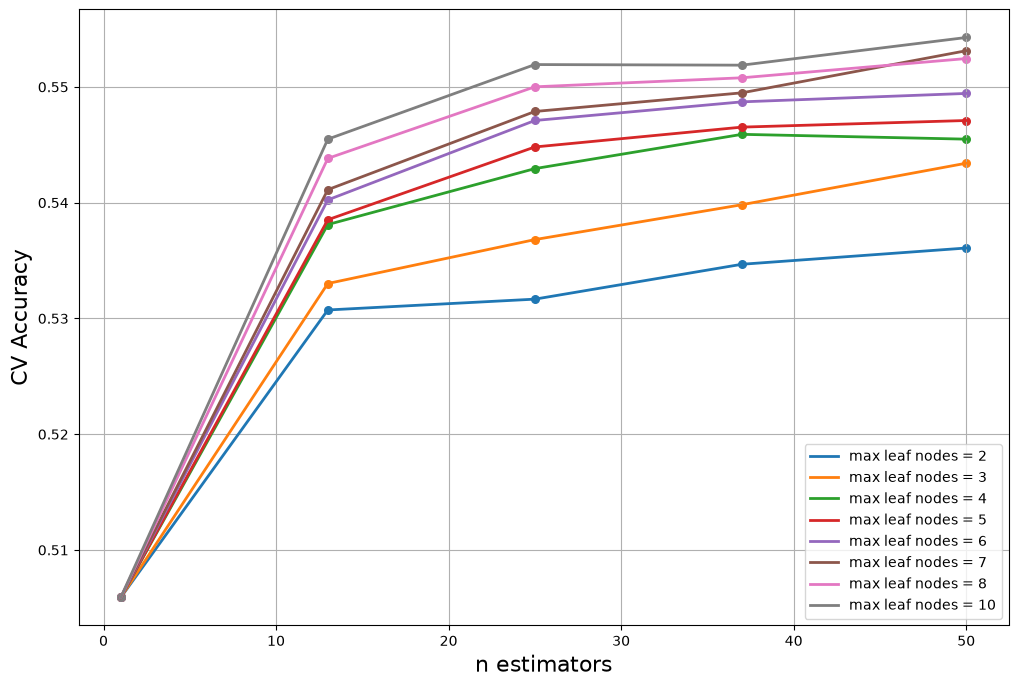

In [100]:
n_estimators = gbc_cv.cv_results_['param_n_estimators'].data
cv_acc_scores = gbc_cv.cv_results_['mean_test_score']

plt.figure(figsize=(12, 8))
plt.xlabel('n estimators', fontsize=16)
plt.ylabel('CV Accuracy', fontsize=16)
plt.grid(True, which='both')

N = len(grid_values['max_leaf_nodes'])
M = len(grid_values['n_estimators'])
for i in range(N):
    plt.scatter(n_estimators[(M*i):(M*i)+M], cv_acc_scores[(M*i):(M*i)+M], s=30)
    plt.plot(n_estimators[(M*i):(M*i)+M], cv_acc_scores[(M*i):(M*i)+M], linewidth=2,
             label='max leaf nodes = '+str(grid_values['max_leaf_nodes'][i]))
plt.legend(loc='lower right')
plt.show()

In [101]:
gb_y_pred = gbc_cv.predict(stack_stats_test_X)
cm3 = confusion_matrix(y_test_binary, gb_y_pred)
print ("Confusion Matrix: \n", cm3)
print ("\nAccuracy:", accuracy_score(y_test_binary, gb_y_pred))
gb_acc = accuracy_score(y_test_binary, gb_y_pred)

Confusion Matrix: 
 [[2779 1394]
 [2376 1700]]

Accuracy: 0.542974906049218


In [102]:
gb_y_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(8249,))

In [103]:
# Gradient Boosting Accuracy
gb_acc

0.542974906049218

In [104]:
# Gradient Boosting TPR
gb_tpr = tpr(gb_y_pred, y_test_binary, y_train_binary)
gb_tpr

np.float64(0.4170755642787046)

In [105]:
# Gradient Boosting FPR
gb_fpr = fpr(gb_y_pred, y_test_binary, y_train_binary)
gb_fpr

np.float64(0.33405224059429667)

### Bootstrapping my Final Model

In [108]:
# %pip install bootstrapped

In [109]:
import bootstrapped.bootstrap as bs
import bootstrapped.stats_functions as bs_stats

* The Logistic Regression model performed the "best" out of all my chosen models, so we will use it as our final model.

In [110]:
import time

def bootstrap_validation(test_data, test_label, train_label, model, metrics_list, sample=500, random_state=66):
    tic = time.time()
    n_sample = sample
    n_metrics = len(metrics_list)
    output_array=np.zeros([n_sample, n_metrics])
    output_array[:]=np.nan
    print(output_array.shape)
    for bs_iter in range(n_sample):
        bs_index = np.random.choice(test_data.index, len(test_data.index), replace=True)
        bs_data = test_data.loc[bs_index]
        bs_label = test_label.loc[bs_index]
        bs_predicted = model.predict(bs_data)
        for metrics_iter in range(n_metrics):
            metrics = metrics_list[metrics_iter]
            output_array[bs_iter, metrics_iter]=metrics(bs_predicted,bs_label,train_label)
#         if bs_iter % 100 == 0:
#             print(bs_iter, time.time()-tic)
    output_df = pd.DataFrame(output_array)
    return output_df

### Bootstrap Output

(5000, 3)
time: 48.78 s


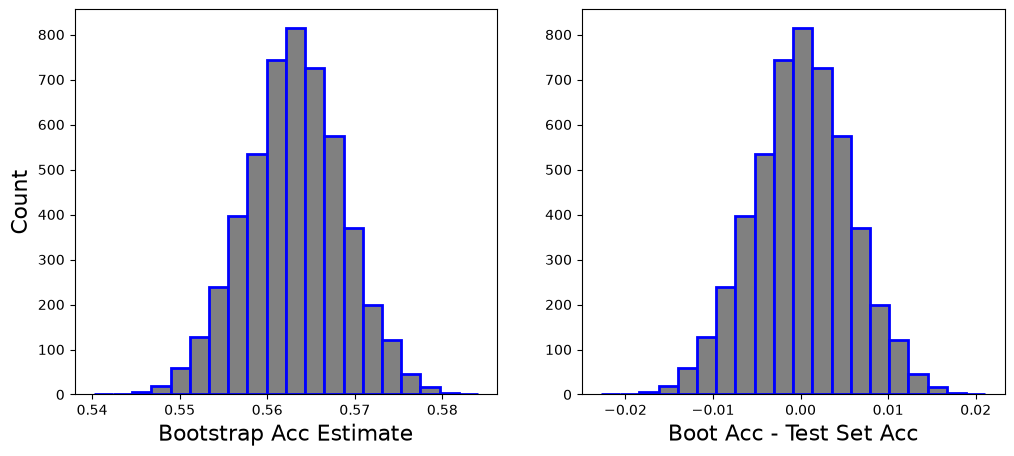

In [111]:
tic = time.time()

bs_output = bootstrap_validation(stack_stats_test_X, y_test_binary, y_train_binary, logreg,
                                 metrics_list=[custom_acc, tpr, fpr],
                                 sample = 5000)

test_acc = custom_acc(y_pred_log, y_test_binary, y_train_binary)

fig, axs = plt.subplots(ncols=2, figsize=(12,5))
axs[0].set_xlabel('Bootstrap Acc Estimate', fontsize=16)
axs[1].set_xlabel('Boot Acc - Test Set Acc', fontsize=16)
axs[0].set_ylabel('Count', fontsize=16)
axs[0].hist(bs_output.iloc[:,0], bins=20,edgecolor='blue', linewidth=2,color = "grey")
axs[1].hist(bs_output.iloc[:,0]-test_acc, bins=20,edgecolor='blue', linewidth=2,color = "grey")

toc = time.time()

print('time:', round(toc-tic, 2),'s')

In [112]:
# The 95% confidence interval for Accuracy
CI= np.quantile(bs_output.iloc[:,0]-test_acc,np.array([0.025,0.975]))
print("The 95-percent confidence interval of Accuracy is %s" % CI)

The 95-percent confidence interval of Accuracy is [-0.01091041  0.01115287]


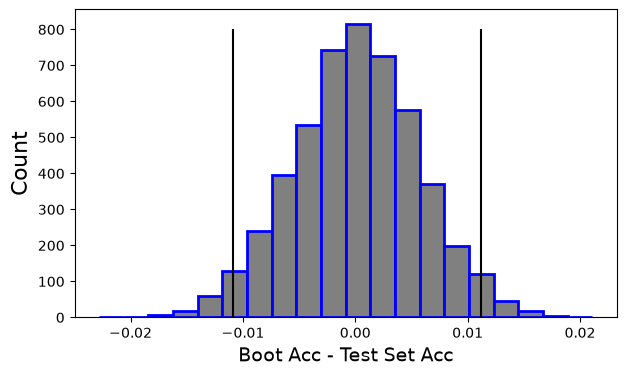

In [113]:
fig, axs = plt.subplots(ncols=1, figsize=(7,4))
axs.set_xlabel('Boot Acc - Test Set Acc', fontsize=14)
axs.set_ylabel('Count', fontsize=16)
axs.hist(bs_output.iloc[:,0]-test_acc, bins=20,edgecolor='blue', linewidth=2,color = "grey")
axs.vlines(x=CI[0], ymin = 0, ymax =800, color = "black")
axs.vlines(x=CI[1], ymin = 0, ymax =800, color = "black")

time: 0.08 s


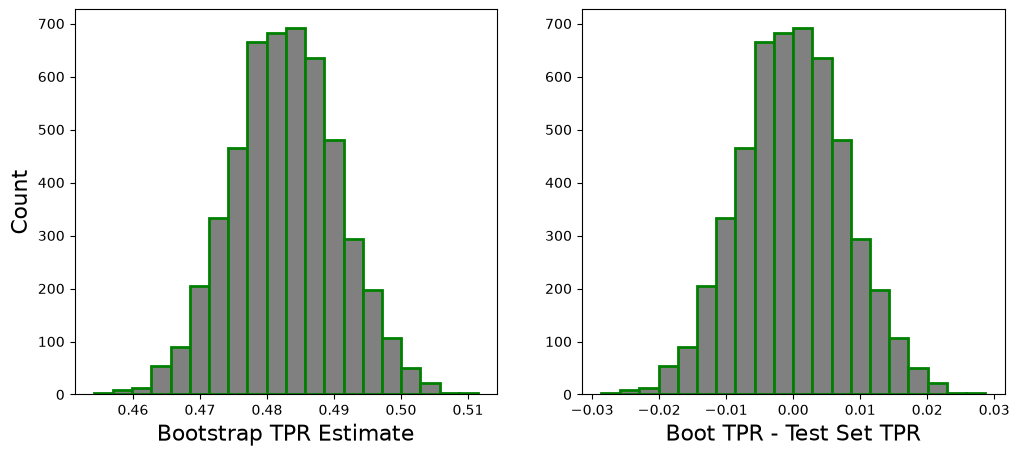

In [114]:
tic = time.time()

test_tpr = tpr(y_pred_log, y_test_binary, y_train_binary)

fig, axs = plt.subplots(ncols=2, figsize=(12,5))
axs[0].set_xlabel('Bootstrap TPR Estimate', fontsize=16)
axs[1].set_xlabel('Boot TPR - Test Set TPR', fontsize=16)
axs[0].set_ylabel('Count', fontsize=16)
axs[0].hist(bs_output.iloc[:,1], bins=20,edgecolor='green', linewidth=2,color = "grey")
axs[1].hist(bs_output.iloc[:,1]-test_tpr, bins=20,edgecolor='green', linewidth=2,color = "grey")

toc = time.time()

print('time:', round(toc-tic, 2),'s')

In [115]:
# The 95% confidence interval for TPR
CI2= np.quantile(bs_output.iloc[:,1]-test_tpr,np.array([0.025,0.975]))
print("The 95-percent confidence interval of the TPR is %s" % CI2)

The 95-percent confidence interval of the TPR is [-0.01540341  0.0157052 ]


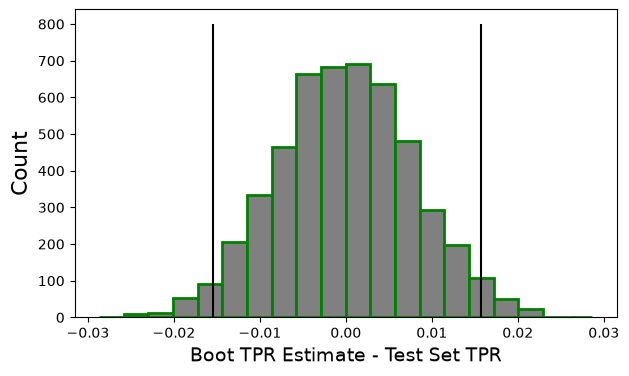

In [117]:
fig2, axs2 = plt.subplots(ncols=1, figsize=(7,4))
axs2.set_xlabel('Boot TPR Estimate - Test Set TPR', fontsize=14)
axs2.set_ylabel('Count', fontsize=16)
axs2.hist(bs_output.iloc[:,1]-test_tpr, bins=20,edgecolor='green', linewidth=2,color = "grey")
axs2.vlines(x=CI2[0], ymin = 0, ymax =800, color = "black")
axs2.vlines(x=CI2[1], ymin = 0, ymax =800, color = "black")

time: 0.05 s


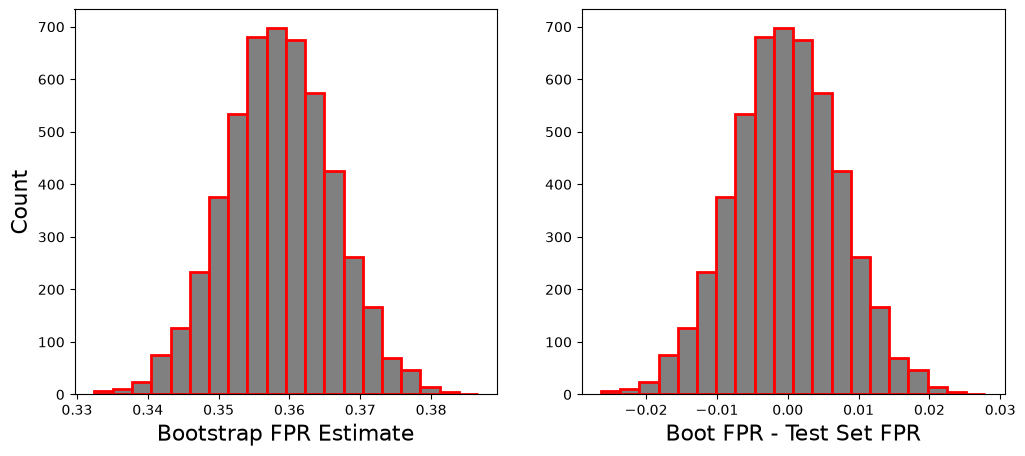

In [118]:
tic = time.time()

test_fpr = fpr(y_pred_log, y_test_binary, y_train_binary)

fig, axs = plt.subplots(ncols=2, figsize=(12,5))
axs[0].set_xlabel('Bootstrap FPR Estimate', fontsize=16)
axs[1].set_xlabel('Boot FPR - Test Set FPR', fontsize=16)
axs[0].set_ylabel('Count', fontsize=16)
axs[0].hist(bs_output.iloc[:,2], bins=20,edgecolor='red', linewidth=2,color = "grey")
axs[1].hist(bs_output.iloc[:,2]-test_fpr, bins=20,edgecolor='red', linewidth=2,color = "grey")

toc = time.time()

print('time:', round(toc-tic, 2),'s')

In [119]:
# The 95% confidence interval for FPR
CI3= np.quantile(bs_output.iloc[:,2]-test_fpr,np.array([0.025,0.975]))
print("The 95-percent confidence interval of the FPR is %s" % CI3)

The 95-percent confidence interval of the FPR is [-0.01524302  0.01475693]


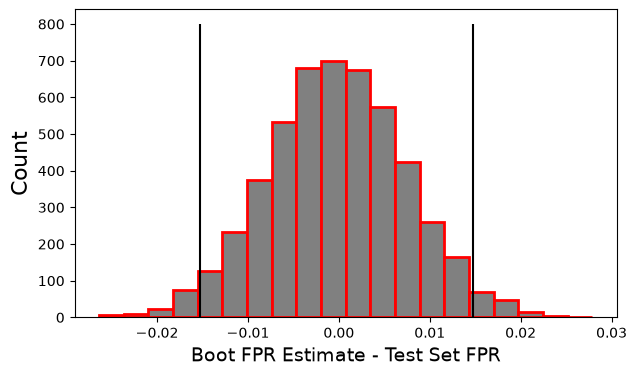

In [120]:
fig3, axs3 = plt.subplots(ncols=1, figsize=(7,4))
axs3.set_xlabel('Boot FPR Estimate - Test Set FPR', fontsize=14)
axs3.set_ylabel('Count', fontsize=16)
axs3.hist(bs_output.iloc[:,2]-test_fpr, bins=20,edgecolor='red', linewidth=2,color = "grey")
axs3.vlines(x=CI3[0], ymin = 0, ymax =800, color = "black")
axs3.vlines(x=CI3[1], ymin = 0, ymax =800, color = "black")

* I decided to go with my Logistic Regression model because it had one of the highest accuracies out of all my models. I also felt that from an interpretability standpoint, it would make sense to use this model to compute both the TPR and FPR. I could generate a confusion matrix from the results and go from there. 

* It also made sense for my problem since we are attempting to predict whether or not a question is useful, based on its tags, title and body text data. A question is useful if its score is greater than or equal to one. Thus when we convert our predictions into binary form to check if the predicted score is greater than or equal to 1, we can utilize logistic regression to help classify each of our datapoints.

* Assessing each of the plots for each of our three metrics(accuracy, TPR, FPR), the results resemble a rough normal distribution. 

* For accuracy, the difference between the test set accuracy and the bootstrapped accuracies do not deviate from 0 too much. Most of the difference is centered at 0, so we won't expect too much of a spread from the original test set accuracy statistic. After constructing a 95% confidence interval, we are 95% confident that the difference between the bootstrapped accuracy and the test set accuracy is between -0.01066796 and 0.0111559. 0 is contained in this interval so there is no statistically significant difference.

* For TPR, the difference between the test set TPR and the bootstrapped TPRs only deviate slightly from 0. The difference is mostly centered around 0, so for the most part there is not too much deviation. We shouldn't expect too much variation for the results on real world data from the original test set TPR statistic. After constructing a 95% confidence interval, we are 95% confident that the differnece between the bootstrapped TPR and the test set TPR is between -0.0152441 and 0.01536173. This range is only slightly bigger than the interval for accuracy. Like before, 0 is contained in this interval so there is no statistically significant difference.

* For FPR, the difference between the test set FPR and the bootstrapped FPRs slightly deviate. The variation is slightly higher than the accuracy's but is not too drastic. Most of the differences are centered around 0, like for accuracy and TPR. We should expect some variance for the results on real world data, but like the TPR results, we shouldn't expect too big a spread from the original test set FPR statistic. After constructing a 95% confidence interval, we are 95% confident that the difference between the bootstrapped FPR and the test set FPR is between -0.01390776 and 0.01429268. Like the others, 0 is contained in this interval so there is no statistically significant difference.

## c) 
* Now, let us consider how Stack Exchange might use your model.  

* In particular, consider  the  following  scenario.  

* When  a  user  navigates  to  the  Cross  Validated  page, they are automatically presented with the 15 most recently submitted questions, in order of most recent first (this is not necessarily true in reality, but let’s pretend that it is). Suppose that Stack Exchange would like to keep these same 15 most recently submitted questions on this page, but they would like to  rearrange  the  order  of  the  questions  so  as  to  show  the  most useful questions at the top of the page.  

* Suppose further that Stack Exchange believes that most users are extremely impatient and will only pay attention to the single question at the very top of the page, and therefore they would like to maximize the probability that the top question is useful.